In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# Métodos Tabulares: Avaliação de políticas em processos decisórios de Markov Finitos

Um processo decisório de Markov finito consiste em um conjunto de *estados* e uma função de dinâmica $p(s', r | s, a)$ que rege a probabilidade de se atingir o estado $s'$ com a recompensa $r$ dado que se parte do estado $s$ e toma-se a ação $a$.

#1. GridWorlds

Os GridWorlds são modelos simples e facilmente visualizáveis de processos decisórios de Markov Finitos.

Nestes modelos um agente se desloca em uma grade discreta bidimensional limitada, tomando ações de deslocamento na horizontal ou vertical.
As ações nem sempre são bem-sucedidas.
Por exemplo, tentativas de movimentos que transportariam o agente para fora da grade podem fazê-lo ficar parado no mesmo lugar.

O livro *Reinforcement Learning, an introduction* por Sutton e Barto, possui diversos exemplos de GridWorlds.

Um exemplo está no capítulo 3:


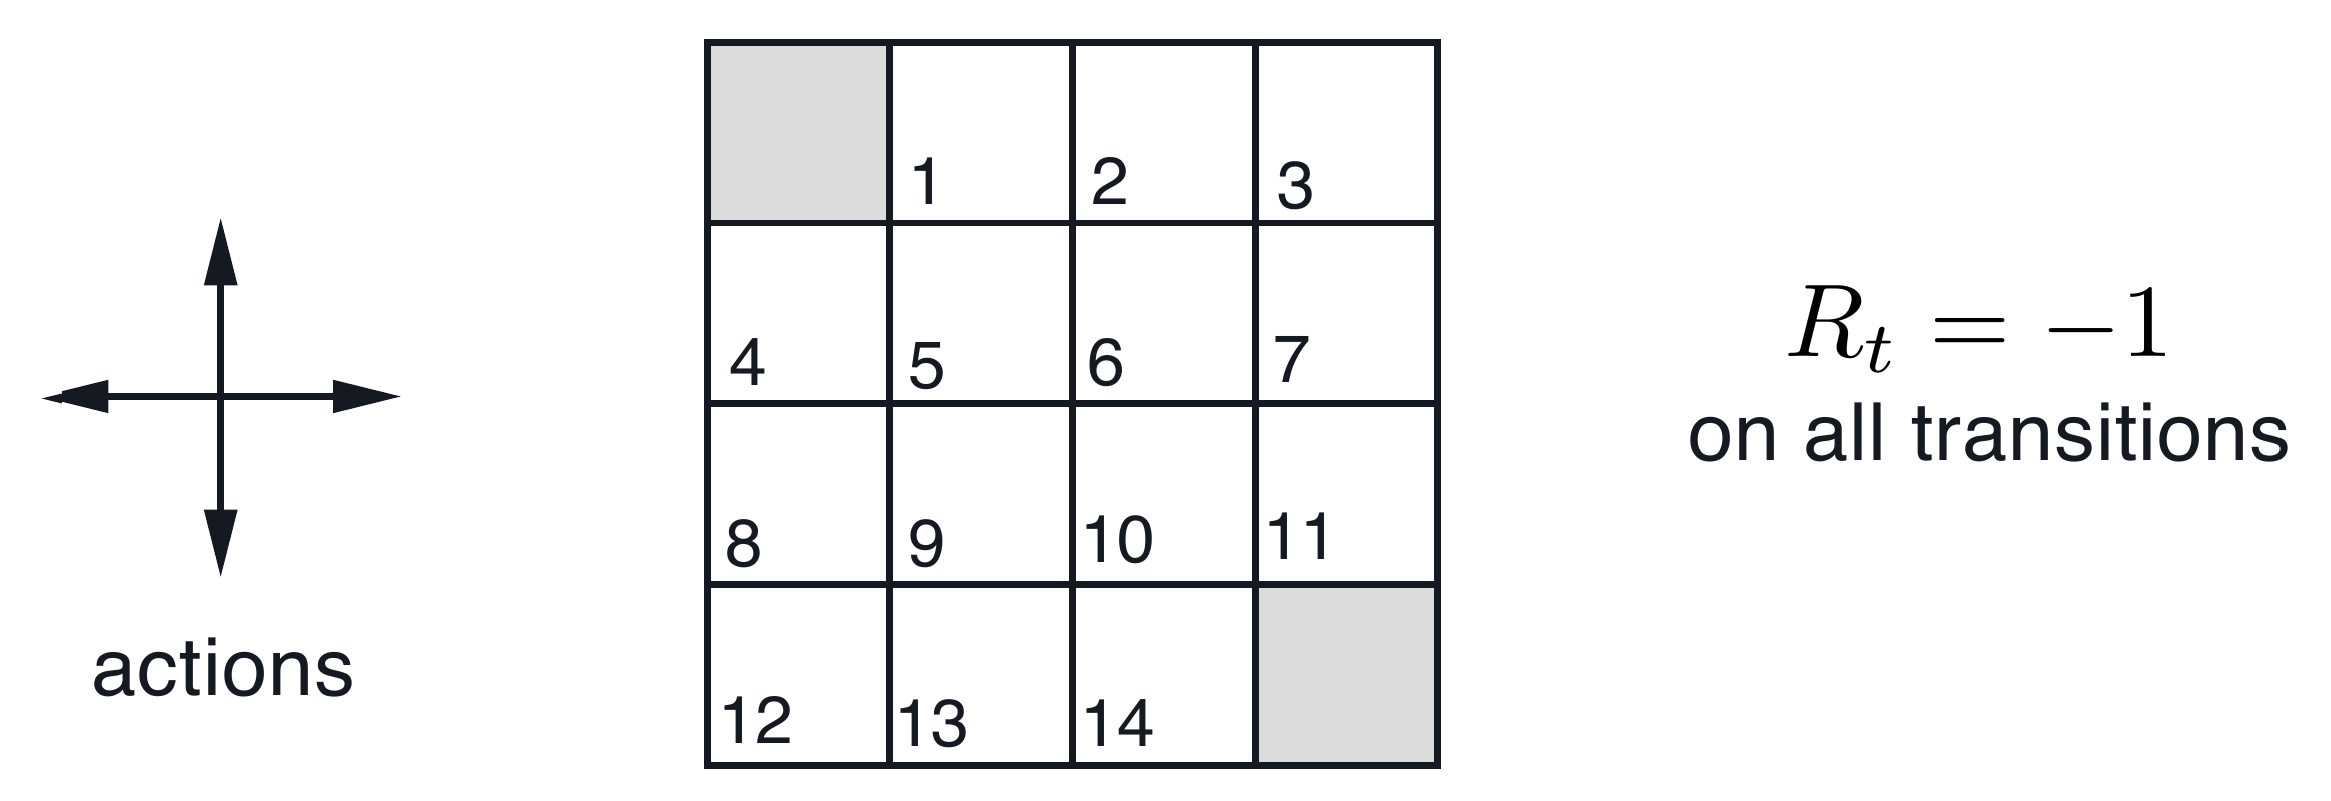

Modelo de GridWorld (repr. de Sutton e Barto 2018)

Neste modelo de uma grade $4 \times 4$ há dois estados terminais, o canto superior esquerdo e o canto inferior direito.
Um agente pode se deslocar na horizontal e vertical, recebendo recompensa -1 em todas as transições.
Deslocamentos que fariam o agente sair da grade mantém-lo na mesma posição.

Nota-se que este modelo é *determinístico*, ou seja, para cada par estado, ação $s, a$ há somente um resultado possível de estado resultante e recompensa $s', r$.

A classe ```ModeloGridWorldDeterministico``` modela este GridWord:

In [3]:
class ModeloGridWorldDeterministico():

  def __init__(self):
    self._estados = set([(i%4,i//4) for i in range(16)])
    self._terminais = {(0,0),(3,3)}
    self._xmax = 3
    self._ymax = 3

  def xmax(self):
    return self._xmax

  def ymax(self):
    return self._ymax

  # Esta função serve apenas para mostrar o grid.
  #  Veja a função acoes_possiveis
  def acao_proibida(self, entrada, saida):
    return entrada[0]<0 or entrada[0]>self._xmax or entrada[1]<0 or entrada[1]>self._ymax or saida[0]<0 or saida[0]>self._xmax or saida[1]<0 or saida[1]>self._ymax

  """
  Retorna um dicionário com todas as possíveis combinações de recompensas e estados resultantes
  quando se parte do estado s e toma-se a ação a.
  """
  def prob_r(self, s , a):
    # Testa se estado é terminal
    if s in self._terminais:
      dest = s
    else:
      dest = (s[0]+a[0], s[1]+a[1])
      # Testa se ação levaria fora da margem
      dest = (max(0, min(3, dest[0])),max(0, min(3, dest[1])))

    # A recompensa é sempre -1
    return {(dest, -1): 1.0}
  """
  Simula o resultado de se tomar a ação a no estado s.
  Retorna uma tupla com o novo estado e a recompensa
  """
  def simula_acao(self, s, a):
    resultados_possiveis = self.prob_r(s, a)
    estados_recompensas = list(resultados_possiveis)
    probabilidades = [resultados_possiveis[e] for e in estados_recompensas]
    return estados_recompensas[np.random.choice(len(estados_recompensas), p=probabilidades)]


  """
  Retorna todas as açoes possíveis a partir do estado s
  """
  def acoes_possiveis(self, s):
    # Todas as ações são possíveis
    return {(-1,0),(1,0),(0,-1),(0,1)}

  def estados_possiveis(self):
    return self._estados

  def estados_terminais(self):
    return self._terminais

  """
  Retorna verdadeiro se o estdo é terminal, falso caso contrário
  """
  def terminal(self, s):
    return s in self._terminais


Nesta classe um estado é representado por uma tupla com o índice da coluna e o índice da linha da célula onde se encontra o agente.

O método ```estados_possiveis(self)``` retorna um conjunto (objeto ```set```) com todos os estados possíveis do sistema.

O método ```acoes_possiveis(self, s)``` retorna um conjunto (objeto ```set```) com todas as ações possíveis a partir do estado ```s```.
Note que nesta classe uma ação é considerada "possível" ainda que tentasse levar o agente para fora da grade.
Deste modo este método *sempre* retorna os 4 movimentos $\{(-1,0), (1,0), (0, -1), (0, 1)\}$.

O método ```estados_terminais(self)``` retorna um conjunto (objeto ```set```) com os estados terminais do sistema (neste caso os estados $\{(0,0),(3,3)\}$).

O método ```prob_r(self, s, a)``` que, dado um estado inicial ```s```e uma ação ```a```, retorna uma tabela de probabilidades discretas que associa tuplas $(s', r)$ de estados resultantes e recompensas a valores de probabilidade.
Esta tabela é retornada na forma de um dicionário.
Cada chave corresponde a uma tupla de estado resultante e recompensa.
O valor correspondente é a probabilidade de se chegar ao estado resultante.

O método ```simula_acao(self, s, a)``` retorna uma tupla com o estado  e a recompensa resultantes de se tomar a ação ```a``` a partir do estado ```s```.


A função ```mostra_grid(modelogrid)``` mostra o GridWorld modelado por ```modelogrid```.

In [4]:
def mostra_grid(modelogrid):
  s = 0.2
  fig, ax = plt.subplots()
  xmax = modelogrid.xmax()
  ymax = modelogrid.ymax()
  # Marca estados terminais
  for e in modelogrid.estados_terminais():
    ax.add_patch(patches.Rectangle((e[0]*s,(ymax-e[1])*s), s, s, color='gray'))
  # Desenha grade horizontal
  for y in range(0, ymax+2):
    for x in range(0, xmax+1):
      proibido = modelogrid.acao_proibida((x,y-1), (x, y))
      ax.plot([x*s, (x+1)*s], [(ymax-y+1)*s,(ymax-y+1)*s], marker=None, color='black', alpha=1.0 if proibido else 0.125)
  # Desenha grade vertical
  for x in range(0, xmax+2):
    for y in range(0, ymax+1):
      proibido = modelogrid.acao_proibida((x-1,ymax-y), (x, ymax-y))
      ax.plot([x*s, (x)*s], [(y)*s,(y+1)*s], marker=None, color='black', alpha=1.0 if proibido else 0.125)


  ax.set_aspect('equal')
  ax.set_xlim([0,s*(xmax+1)])
  ax.set_ylim([0,s*(ymax+1)])
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
  ax.set_axis_off()
  fig.show()


C:\Users\mathe\AppData\Local\Temp\ipykernel_16132\2250059387.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


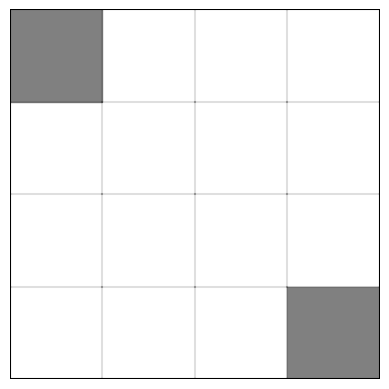

In [5]:
mostra_grid(ModeloGridWorldDeterministico())


O modelo implementado pela classe ```ModeloGridWorldDeterministico```, ou seja, o dicionário retornado por ```prob_r``` só tem uma chave com probabilidade 1.

Uma variação possível deste modelo é uma em que há uma probabilidade $p$ do agente ficar *parado* no mesmo lugar, ainda que o movimento que ele tenha tentado fazer fosse legal.

A classe ```ModeloGridWorldProbabilistico``` implementa esta variação:

In [6]:
class ModeloGridWorldProbabilistico(ModeloGridWorldDeterministico):

  def __init__(self, p):
    self._p = p
    super().__init__()

  """
  Retorna um dicionário com todas as possíveis combinações de recompensas e estados resultantes
  quando se parte do estado s e toma-se a ação a.
  """
  def prob_r(self, s , a):
    det = super().prob_r(s,a)
    if self._p>0:
      for r in det:
          det[r] *= (1-self._p)
      det[(s, -1)] = det.get((s, -1), 0) + self._p
    return det


Observa-se por exemplo que ao partir da célula $(1,1)$ e se deslocar para a direita $(1,0)$, há somente uma possibilidade no modelo deterministico, a de se chegar na casa $(2,1)$ com recompensa -1.

No modelo probabilístico com p=50\%, há dois resultados possíveis, ficar no estado $(1,1)$ com probabilidade 50\% e ir para o estado $(2,1)$ com probabilidade 50\%.
Em ambos os casos a recompensa é de -1.

In [7]:
print(ModeloGridWorldDeterministico().prob_r((1,1),(1,0)))
print(ModeloGridWorldProbabilistico(0.5).prob_r((1,1),(1,0)))


{((2, 1), -1): 1.0}
{((2, 1), -1): 0.5, ((1, 1), -1): 0.5}


## Exercício:

Embora em geral o modelo da classe ```ModeloGridWorldProbabilistico``` tenha múltiplos resultados possíveis para pares estado/ação, algumas combinações de estado e ação são *determinísticas*, ou seja, há apenas *um* resultado possível.

Escreva em python um código que mostra *todos* os pares estado/ação *determinísticos* (ou seja, para os quais o dicionário retornado por ```prob_r``` só tem uma entrada) com os correspondentes resultados.

Explique o que são estes estados

In [ ]:
modeloprobabilistico = ModeloGridWorldProbabilistico(0.5)
for s in modeloprobabilistico.estados_possiveis():
  # Complete com seu código


# Retornos, políticas e valores de estados

Suponha que um agente passa por uma sequência de estados $s_0, \ldots, s_n$ com $s_n$ terminal e recebe uma correspondente sequência de recompensas $r_1, \ldots, r_n$, então o *retorno* do episódio a partir do instante $t$ é dado por:

\begin{equation}
G_t = \sum_{t+1}^n r_t
\end{equation}

Nota-se que mesmo que as recompensas sejam limitadas, em geral o retorno só está definido para episódios que atingem o estado terminal em tempo finito.

Uma alternativa para esta definição é o conceito de *desconto*.
Nesta definição, é aplicado um fator de desconto $\gamma<1$.
Neste caso pode-se definir de forma mais geral:

\begin{equation}
G_t = \sum_{k=0}^\infty \gamma^k r_{t+k+1}
\end{equation}

note que para sistemas que atingem o estado final no instante $n$, $r_t=0$ para $t>n$.

Nota-se que vale:

\begin{equation}
G_t = r_{t+1} + \gamma G_{t+1}
\end{equation}

Por exemplo, suponha que um agente no gridword descrito acima começa no estado $(0,3)$ e desloca-se sempre para a direita.
Neste caso a sequência de recompensas é -1, -1, -1, quando ele finalmente atinge o estado terminal.
Se adotarmos $\gamma=1/2$, o retorno total deste episódio é $-1,75$.

Uma *política* neste contexto pode ser vista como uma distribuição de probabilidades $\pi(a | s)$ que rege a probabilidade de um agente tomar a ação $a$ a partir do estado $s$.

Podemos definir o *valor* de um estado $s$ dada uma política $\pi$, $v_\pi (s)$ como o *valor esperado* do retorno de um agente parte do estado $s$ e a partir dele age de acordo com a política $\pi$.

\begin{equation}
v_\pi (s) = \mathbb{E}_\pi \left[\left.\sum_{k=0}^\infty \gamma^k r_{t+k+1}\right|s_t = s\right]
\end{equation}

De certa forma, o valor $v_\pi(s)$ é uma medida do "quão bom" é estar no estado $s$ quando se segue a política $\pi$.


## Exercício:

Podemos escrever em Python funções que descrevem políticas.
Estas funções recebem 2 argumentos, um estado $s$ e uma ação $a$.
Elas retornam a probabilidade, segundo a política descrita, de se tomar a ação $a$ a partir do estado $s$.

A função ```cria_func_politica_aleatoria_uniforme(modelo)``` cria uma nova função (sim, é uma função que cria uma função) que descreve uma política aleatória uniforme, ou seja, esta política tem probabilidade igual de tomar quaisquer das ações possíveis a partir do estado $s$.

In [ ]:
def cria_func_politica_aleatoria_uniforme(modelo):
  def func_politica_aleatoria(s, a):
    # Todas as ações são igualmente possíveis
    return 1/len(modelo.acoes_possiveis(s)) if a in modelo.acoes_possiveis(s) else 0
  return func_politica_aleatoria

# Cria uma função que escolhe ação a partir da função probabilidade e do modelo
def cria_politica_aleatoria(modelo, funcao_prob):
  def funcao_politica_aleatoria(s):
    acoes_possiveis = list(modelo.acoes_possiveis(s))
    indice = np.random.choice(len(acoes_possiveis), p=[funcao_prob(s, a) for a in acoes_possiveis])
    return acoes_possiveis[indice]
  return funcao_politica_aleatoria


Exemplo:

In [ ]:
modelo_deterministico = ModeloGridWorldDeterministico()
funcao_probabilidade = cria_func_politica_aleatoria_uniforme(modelo_deterministico)
estado = (0,1)
for acao in modelo_deterministico.acoes_possiveis(estado):
  print("Chance de se tomar a ação " + str(acao) + " a partir do estado " + str(estado) + ": " + str(funcao_probabilidade(estado, acao)))
# Exemplo de ação impossível
print("Chance de se tomar a ação " + str((1,1)) + " a partir do estado " + str(estado) + ": " + str(funcao_probabilidade(estado, (1,1))))


Complete a implementação da função ```simula_episodio(modelo, estado_inicial, funcao_agente, gamma)``` que simula um episódio de um agente interagindo com o modelo dado por ```modelo```, partindo de ```estado_inicial```  e seguindo a política descrita pela função ```funcao_agente```.
A função deve calcular o retorno do episódio usando a taxa de desconto ```gamma```.

*Sugestão*. Para cada estado há diversas ações possíveis.
Construa duas listas.
Uma delas deve conter todas as ações possíveis.
Outra deve conter a correspondente probabilidade de cada ação, tal como calculada pela ```funcao_agente```.
Use a função ```np.random.choice``` passando o comprimento das listas como primeiro parâmetro e a lista de probabilidades como parâmetro ```p``` para sortear o índice da ação a ser tomada.

In [ ]:
def simula_episodio(modelo, estado_inicial, funcao_agente, gamma):
  estado = estado_inicial
  fator = 1.0
  retorno = 0.0
  while estado not in modelo_deterministico.estados_terminais():
    # Complete com seu código
    #   Você deve definir o valor da variável acao, correspondente à
    #   ação aleatória que o agente toma.
    estado, recompensa = modelo.simula_acao(estado, acao)
    retorno += recompensa*fator
    fator *= gamma
  return retorno


Teste seu código com o modelo determinístico.
Partindo-se do estado $(1,1)$, o retorno médio deve ser próximo de $-18$.

In [ ]:
modelo_deterministico = ModeloGridWorldDeterministico()
politica_aleatoria = cria_func_politica_aleatoria_uniforme(modelo_deterministico)
n = 1000
tot = 0.0
for i in range(n):
  tot += simula_episodio(modelo_deterministico, (1,1), politica_aleatoria, 1.0)
print("Retorno médio após " + str(n) + " episódios: " + str(tot/n))


Teste também com o modelo probabilístico.
Note que o resultado deve ser aproximadamente o dobro do retorno do modelo determinístico (Por quê?).

In [ ]:
modelo_probabilistico = ModeloGridWorldProbabilistico(0.5)
politica_aleatoria = cria_func_politica_aleatoria_uniforme(modelo_deterministico)
n = 1000
tot = 0.0
for i in range(n):
  tot += simula_episodio(modelo_probabilistico, (1,1), politica_aleatoria, 1.0)
print("Retorno médio após " + str(n) + " episódios: " + str(tot/n))


# Avaliação de Política

Pela definição da função $v_\pi (s)$ acima, tem-se:

\begin{equation}
v_\pi(s) = \sum_a \pi(a | s) \sum_{s', r} p(s', r | a, s) \left(r + \gamma v_\pi(s') \right)
\end{equation}

Esta é a célebre equação de Bellman para o valor do estado, e estabelece uma relação linear entre o valor do estado $s$ dado por $v_\pi(s)$ e os valores dos possíveis estados sucessores $v_\pi(s')$.

Aplicando-se esta equação a todos os estados possíveis do sistema, tem-se um sistema linear cuja solução leva ao valor, segundo a política $\pi$ de cada um dos estados.

Embora haja diversas maneiras de se resolver numericamente este sistema, mostra-se que uma simples iteração é convergente, deste que os retornos esperados do sistema sejam finitos.
Sendo ${V_\pi}_k(s)$ uma estimativa para $v_\pi(s)$, então uma versão *melhorada* dessa estimativa ${V_\pi}_{k+1}(s)$ é dada por:

\begin{equation}
{V_\pi}_{k+1}(s) = \sum_a \pi(a | s) \sum_{s', r} p(s', r | a, s) \left(r + \gamma {V_\pi}_k(s') \right)
\end{equation}

Repete-se a iteração até que a máxima variação seja inferior a um parâmetro determinado.


## Exercício

Complete a função ``` avalia_politica_probabilistica(modelo, funcao_prob, gamma, theta)``` que avalia uma política.

Esta função recebe um modelo, uma função de probabilidade correspondente a uma política, um valor $\gamma$ e um critério de convergência $\theta$.

Esta função devolve uma avaliação da política definida pela função de probabilidade na forma de um *dicionário*.
Este dicionário associa estados a valores.


In [ ]:
def avalia_politica_probabilistica(modelo, funcao_prob, gamma, theta):
  todos_os_estados = list(modelo.estados_possiveis())
  v = {}
  for estado in todos_os_estados:
    v[estado] = 0.0
  delta = 1
  while delta > theta:
    v_antigo = dict(v) # Copia a estimativa atual
    # Variação máxima
    delta = 0.0
    # Avalia cada um dos estados possíveis
    for s in todos_os_estados:
      if s in modelo.estados_terminais():
        # Pula estados terminais
        continue
      # Complete com seu código
      #   Aqui você deve calcular o novo valor de v[s] considerando todas as ações
      #   possiveis, todos os resultados possíveis e a
      #   estimativa antiga na variável v_antigo

      # Procura a variação máxima
      delta = max(delta, abs(v[s]-v_antigo[s]))
  return v


Teste seu código.
Você deve obter resultados similares ao do livro do Sutton:
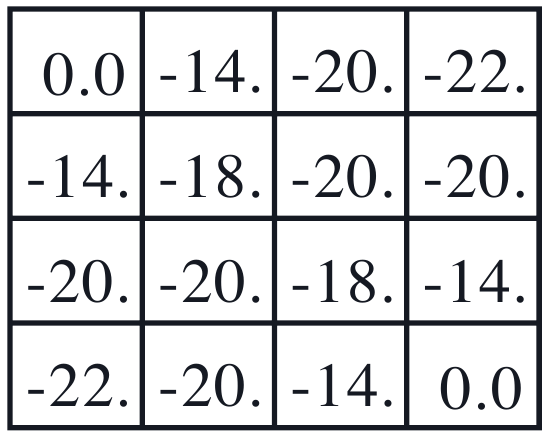

In [ ]:
modelo_deterministico = ModeloGridWorldDeterministico()
funcao_probabilidade = cria_func_politica_aleatoria_uniforme(modelo_deterministico)
v_politica_aleatoria_uniforme = avalia_politica_probabilistica(modelo_deterministico, funcao_probabilidade, 1.0, 0.0000001)


In [ ]:
def mostra_avaliacao(modelogrid, v):
  s = 0.2
  fig, ax = plt.subplots()
  xmax = modelogrid.xmax()
  ymax = modelogrid.ymax()
  # Marca estados terminais
  for e in modelogrid.estados_terminais():
    ax.add_patch(patches.Rectangle((e[0]*s,(ymax-e[1])*s), s, s, color='gray'))
  # Desenha grade horizontal
  for y in range(0, ymax+2):
    for x in range(0, xmax+1):
      proibido = modelogrid.acao_proibida((x,y-1), (x, y))
      ax.plot([x*s, (x+1)*s], [(ymax-y+1)*s,(ymax-y+1)*s], marker=None, color='black', alpha=1.0 if proibido else 0.25)
  # Desenha grade vertical
  for x in range(0, xmax+2):
    for y in range(0, ymax+1):
      proibido = modelogrid.acao_proibida((x-1,ymax-y), (x, ymax-y))
      ax.plot([x*s, (x)*s], [(y)*s,(y+1)*s], marker=None, color='black', alpha=1.0 if proibido else 0.25)
  for i in range(xmax+1):
    for j in range(ymax+1):
      ax.text((i+0.5)*s, (ymax-j+0.5)*s, str(round(100*v[(i,j)])/100), horizontalalignment='center', verticalalignment='center')
  ax.set_aspect('equal')
  ax.set_xlim([0,s*(xmax+1)])
  ax.set_ylim([0,s*(ymax+1)])
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
  ax.set_axis_off()
  fig.show()


In [ ]:
mostra_avaliacao(modelo_deterministico, v_politica_aleatoria_uniforme)


Teste também com o modelo probabilístico.
Observe que novamente os valores devem ser o dobro dos obtidos no modelo determinístico:
.

In [ ]:
modelo_probabilistico = ModeloGridWorldProbabilistico(0.5)
funcao_probabilidade = cria_func_politica_aleatoria_uniforme(modelo_probabilistico)
v_politica_aleatoria_uniforme_prob = avalia_politica_probabilistica(modelo_probabilistico, funcao_probabilidade, 1.0, 0.0000001)
mostra_avaliacao(modelo_probabilistico, v_politica_aleatoria_uniforme_prob)


# Exercício

Implemente uma função de probabilidade de política para um agente que tenta somente se mover para *a direita* (ação $(1, 0)$).

Avalie esta política no GridWord determinístico com $\gamma=1/2$.
Compare o obtido na casa $(0,3)$ com o valor esperado.

O que aconteceria com a avaliação desta política com $\gamma=1$?
Por quê?

In [ ]:
modelo_deterministico = ModeloGridWorldDeterministico()
def funcao_probabilidade_para_a_direita(s, a):
  # Complete com seu código

v_politica_para_direita = avalia_politica_probabilistica(modelo_deterministico, funcao_probabilidade_para_a_direita, 0.5, 0.0000001)
mostra_avaliacao(modelo_probabilistico, v_politica_para_direita)


# Melhoria e Iteração de Política

Viu-se que a partir de uma política $\pi$ é possível associar *valores* para cada um dos estados $v_\pi(s)$.

Mostra-se no entanto que a partir destes valores é possível criar uma política $\pi^{+}$ *melhorada*.

Esta nova política é determinística e consiste em, a cada estado $s$, selecionar a ação $a$ que *maximiza* o valor

\begin{equation}
\sum_{s', r} p(s', r | s, a) \left[r + \gamma v_\pi(s')\right]
\end{equation}

Mostra-se que esta política determinística é melhor que a anterior, ou seja, $v_{\pi^{+}}(s) \geq v_\pi(s)$ para *todos* os estados.


## Exercício

Uma política determinística pode ser descrita como um *dicionário* no qual cada chave é um estado possível para o sistema e o valor correspondente é a ação que deve ser tomada naquele estado.

Complete a função ```cria_tabela_politica_melhorada_para_v(modelo, v, gamma)``` que constrói uma tabela com uma política melhorada partindo da avaliação de uma política anterior passada pelo dicionário ```v```.

Esta função deve selecionar dentre todas as ações possíveis a que maximiza a quantidade descrita acima

In [ ]:
def cria_tabela_politica_melhorada_para_v(modelo, v, gamma):
  pol = {}
  # Para cada estado
  for e in modelo.estados_possiveis():
    melhor = -float('inf')
    # Complete com seu código
    #   Você deve encontrar a ação que maximiza o valor descrito acima

    pol[e] = melhor_acao
  return pol


Teste seu código.
Vamos inicialmente avaliar a política puramente aleatória.
A partir desta avaliação vamos construir uma política melhorada.
Observe como os valores de todos os estados são maiores ou iguais aos da política anterior.

In [ ]:
modelo_deterministico = ModeloGridWorldDeterministico()
funcao_probabilidade = cria_func_politica_aleatoria_uniforme(modelo_deterministico)
v_politica_aleatoria_uniforme = avalia_politica_probabilistica(modelo_deterministico, funcao_probabilidade, 1.0, 0.0000001)
mostra_avaliacao(modelo_deterministico, v_politica_aleatoria_uniforme)


In [ ]:
tabela_politica_melhorada = cria_tabela_politica_melhorada_para_v(modelo_deterministico, v_politica_aleatoria_uniforme, 1.0)


In [ ]:
# Esta função cria uma nova função probabilidade a partir de uma tabela de estados->ações
def cria_funcao_prob_politica_deterministica(tabela):
  def func_politica_aleatoria(s, a):
    # Apenas a ação da tabela tem probabilidade 1, outras são 0
    return 1.0 if tabela[s]==a else 0.0
  return func_politica_aleatoria


In [ ]:
v_politica_melhorada = avalia_politica_probabilistica(modelo_deterministico, cria_funcao_prob_politica_deterministica(tabela_politica_melhorada), 1.0, 0.0000001)
mostra_avaliacao(modelo_deterministico, v_politica_melhorada)


In [ ]:
def mostra_politica(modelogrid, funcao_prob):
  s = 0.4
  fig, ax = plt.subplots()
  xmax = modelogrid.xmax()
  ymax = modelogrid.ymax()
  # Marca estados terminais
  for e in modelogrid.estados_terminais():
    ax.add_patch(patches.Rectangle((e[0]*s,(ymax-e[1])*s), s, s, color='gray'))
  # Desenha grade horizontal
  for y in range(0, ymax+2):
    for x in range(0, xmax+1):
      proibido = modelogrid.acao_proibida((x,y-1), (x, y))
      ax.plot([x*s, (x+1)*s], [(ymax-y+1)*s,(ymax-y+1)*s], marker=None, color='black', alpha=1.0 if proibido else 0.25)
  # Desenha grade vertical
  for x in range(0, xmax+2):
    for y in range(0, ymax+1):
      proibido = modelogrid.acao_proibida((x-1,ymax-y), (x, ymax-y))
      ax.plot([x*s, (x)*s], [(y)*s,(y+1)*s], marker=None, color='black', alpha=1.0 if proibido else 0.25)
  for i in range(xmax+1):
    for j in range(ymax+1):
      if (i,j) in modelogrid.estados_terminais():
        continue  # Não desenha setas para estados terminais
      for a in modelogrid.acoes_possiveis((i,j)):
        p = funcao_prob((i,j),a)
        if p>0:
          ax.arrow((i+0.5)*s, (ymax-j+0.5)*s, a[0]*s/2, -a[1]*s/2, head_width=s/10, color = 'red', length_includes_head=True)
          ax.text((i+0.5)*s + a[0]*s/5, (ymax-j+0.5)*s -a[1]*s/5, str(round(100*p)/100), horizontalalignment='center', verticalalignment='center', fontsize='xx-small')
  ax.set_aspect('equal')
  ax.set_xlim([0,s*(xmax+1)])
  ax.set_ylim([0,s*(ymax+1)])
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
  ax.set_axis_off()
  fig.show()


O código abaixo mostra com setas qual a política determinística selecionada:

In [ ]:
mostra_politica(modelo_deterministico, cria_funcao_prob_politica_deterministica(tabela_politica_melhorada))


Se esta política levar sempre a um estado terminal, podemos mostrar o seu caminho no gridword:

In [ ]:
# Encontra uma rota até um estado terminal dada uma tabela de política
# determinística
def cria_saida(modelogrid, estado_inicial, tabela_politica_saida):
  trajetoria = [estado_inicial]
  estados_finais = modelogrid.estados_terminais()
  while trajetoria[-1] not in estados_finais:
    a = tabela_politica_saida[trajetoria[-1]]
    trajetoria.append((trajetoria[-1][0] + a[0], trajetoria[-1][1] + a[1]))
  return trajetoria

def mostra_trajetoria(modelogrid, trajetoria):
  s = 0.4
  fig, ax = plt.subplots()
  xmax = modelogrid.xmax()
  ymax = modelogrid.ymax()
  # Marca estados terminais
  for e in modelogrid.estados_terminais():
    ax.add_patch(patches.Rectangle((e[0]*s,(ymax-e[1])*s), s, s, color='gray'))
  # Desenha grade horizontal
  for y in range(0, ymax+2):
    for x in range(0, xmax+1):
      proibido = modelogrid.acao_proibida((x,y-1), (x, y))
      ax.plot([x*s, (x+1)*s], [(ymax-y+1)*s,(ymax-y+1)*s], marker=None, color='black', alpha=1.0 if proibido else 0.25)
  # Desenha grade vertical
  for x in range(0, xmax+2):
    for y in range(0, ymax+1):
      proibido = modelogrid.acao_proibida((x-1,ymax-y), (x, ymax-y))
      ax.plot([x*s, (x)*s], [(y)*s,(y+1)*s], marker=None, color='black', alpha=1.0 if proibido else 0.25)
  t = np.array(trajetoria, dtype=float).T
  t[1] = ymax - t[1]
  t += 0.5
  t *= s
  ax.plot(t[0],t[1], color='red')
  ax.set_aspect('equal')
  ax.set_xlim([0,s*(xmax+1)])
  ax.set_ylim([0,s*(ymax+1)])
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
  ax.set_axis_off()
  fig.show()


In [ ]:
mostra_trajetoria(modelo_deterministico, cria_saida(modelo_deterministico, (1,2), tabela_politica_melhorada))


# Iteração de Valor

A melhoria de política sugere um processo para se encontrar a *política ótima*.
Parte-se de uma política inicial (por exemplo, uma política aleatória uniforme) e constrói-se a a avaliação desta política.

A partir desta avaliação, constrói-se uma nova política melhorada.

Repete-se o processo até a convergência, avaliando-se a política e com esta avaliação construindo-se uma nova política melhorada.

Este processo possui convergência razoável para problemas como o GridWorld visto acima, mas pode ser muito lento para outros processos.

Uma alternativa mais rápido é *fundir* os dois processos para avaliar diretamente a função $v_{\pi^{*}}(s)$ da política ótima $\pi^{*}$.

De modo análogo ao feito em avaliação de política, seja $V_{k}(s)$ uma estimativa para $v_{\pi^{*}}(s)$.
Então uma estimativa *melhor* é dada por:

\begin{equation}
{V}_{k+1}(s) = \underset{a}{\mbox{max}}  \sum_{s', r} p(s', r | a, s) \left(r + \gamma {V}_k(s') \right)
\end{equation}

Mostra-se que para todos processos decisório de Markov finitos com $\gamma < 1$ os valores de $V_k(s)$ convergem para a função da política ótima $v_{\pi^{*}}(s)$.

A correspondente política ótima é a que em cada estado $s$ seleciona a ação $a$ que minimiza o valor:

\begin{equation}
\sum_{s', r} p(s', r | s, a) \left[r + \gamma v_{\pi^{*}}(s')\right]
\end{equation}

Note que este é exatamente o mesmo procedimento para encontrar-se a política melhorada a partir de uma avaliação de outra política.


# Exemplo: Labirinto

É possível usar as técnicas vistas aqui para resolver labirintos.

A classe ```ModeloGridWorldLabirintoDeterministico``` modela um GridWorld com barreiras entre as células.
Caso um agente tente atravessar uma barreira, fica no mesmo lugar.
Este modelo produz recompensa zero para todas as transições, exceto para a que atinge o resultando final, quando a recompensa é 1.

O código que gera o labirinto aleatório é baseado em árvores geradoras aleatórias de grafos e é derivado do trabalho de [Peter Norvig](https://github.com/norvig/pytudes/blob/main/ipynb/Maze.ipynb).

In [ ]:
import random
from collections import deque, namedtuple
Edge = tuple
Tree = set
def edge(A, B) -> Edge: return Edge(sorted([A, B]))
def random_tree(nodes, neighbors, pop=deque.pop) -> Tree:
    tree = Tree()
    nodes = set(nodes)
    root = nodes.pop()
    frontier = deque([root])
    while nodes:
        node = pop(frontier)
        nbrs = neighbors(node) & nodes
        if nbrs:
            nbr = random.choice(list(nbrs))
            tree.add(edge(node, nbr))
            nodes.remove(nbr)
            frontier.extend([node, nbr])
    return tree
Maze = namedtuple('Maze', 'width, height, edges')
Square = tuple
def neighbors4(square) -> {Square}:
    (x, y) = square
    return {(x + 1, y), (x - 1, y), (x, y + 1), (x, y - 1)}
def grid(width, height) -> {Square}:
    return {(x, y) for x in range(width) for y in range(height)}
def random_maze(width, height, pop=deque.pop) -> Maze:
    tree = random_tree(grid(width, height), neighbors4, pop)
    return Maze(width, height, tree)

class ModeloGridWorldLabirintoDeterministico(ModeloGridWorldDeterministico):
  def __init__(self, maze):
    super().__init__()
    self._xmax = maze.width-1
    self._ymax = maze.height-1
    self._arestas = maze.edges
    self._estados = set([(i%(self._xmax+1),i//(self._xmax+1)) for i in range((self._xmax+1)*(self._ymax+1))])
    self._terminais = {(0,0)}

  def acao_proibida(self, entrada, saida):
    return ((entrada, saida) not in self._arestas) and ((saida, entrada) not in self._arestas)

  def prob_r(self, s , a):
    # Testa se estado é terminal
    if s in self._terminais:
      dest = s
      r = 0.0
    else:
      dest = (s[0]+a[0], s[1]+a[1])
      # Testa se ação é permitida
      if self.acao_proibida(s, dest):
        dest = s
      # A recompensa é 0 se não atingiu estado terminal, senão 1
      r = 1.0 if dest in self._terminais else 0.0
    return {(dest, r): 1.0}


A variável ```modelogridworldlabirinto``` contém o modelo.
Observe como o estado final é o do canto superior direito.
O caminho até ele não é óbvio.

In [ ]:
modelogridworldlabirinto = ModeloGridWorldLabirintoDeterministico(random_maze(12,12))

mostra_grid(modelogridworldlabirinto)


## Exercício

Complete a função ```encontra_v_para_politica_otima(modelo, v0, gamma, theta)```.

In [ ]:
def encontra_v_para_politica_otima(modelo, v0, gamma, theta):
  todos_os_estados = list(modelo.estados_possiveis())
  v = dict(v0)
  delta = 2*theta
  while delta > theta:
    v_antigo = dict(v)
    delta = 0.0
    for i, s in enumerate(todos_os_estados):
      if s in modelo.estados_terminais():
        continue
      melhor = -float('inf')
      # Complete com seu código
      #   Aqui você deve procurar para todas as possíveis ações
      #   qual o máximo valor da expressão acima.
      #   Atribua-o à variável melhor

      v[s] = melhor
      # Procura a variação máxima
      delta = max(delta, abs(v[s]-v_antigo[s]))
  return v


In [ ]:
v0 = {} # Inicializa a estimativa inicial com valores aleatórios, exceto no estado terminal, onde v deve valer zero
for s in modelogridworldlabirinto.estados_possiveis():
    v0[s] = np.random.rand()
for s in modelogridworldlabirinto.estados_terminais():
    v0[s] = 0

v_otimo_para_labirinto = encontra_v_para_politica_otima(modelogridworldlabirinto, v0, 0.95, 0.0000001)


In [ ]:
mostra_avaliacao(modelogridworldlabirinto, v_otimo_para_labirinto)


In [ ]:
tabela_politica_otima_labirinto=cria_tabela_politica_melhorada_para_v(modelogridworldlabirinto, v_otimo_para_labirinto, 0.95)
mostra_politica(modelogridworldlabirinto, cria_funcao_prob_politica_deterministica(tabela_politica_otima_labirinto))


É possível mostrar o caminho seguido até sair do labirinto:

In [ ]:
# Encontra a posição mais distante de um estadot terminal
estados_finais = list(modelogridworldlabirinto.estados_terminais())
todos_estados = list(modelogridworldlabirinto.estados_possiveis())
# Distancia euclideana ao quadrado
def calcula_distancia(e1, e2):
  dx = e1[0]-e2[0]
  dy = e1[1]-e2[1]
  return dx*dx + dy*dy

def menor_distancia(e, estados):
  e2 = estados[0]
  mind = calcula_distancia(e, e2)
  for i in range(1, len(estados)):
    d = calcula_distancia(e, estados[i])
    if d<mind:
      mind = d
      e2 = estados[i]
  return (e2, mind)

# Encontra o ponto mais distante (euclideana) de um estado terminal
estado_mais_distante = todos_estados[0]
_, maior_distancia = menor_distancia(estado_mais_distante, estados_finais)
for i in range(1, len(todos_estados)):
  _, d = menor_distancia(todos_estados[i], estados_finais)
  if d > maior_distancia:
    estado_mais_distante = todos_estados[i]
    maior_distancia = d

# Encontra uma rota até um estado terminal dada uma tabela de política
# determinística
def cria_saida(modelogrid, estado_inicial, tabela_politica_saida):
  trajetoria = [estado_inicial]
  estados_finais = modelogrid.estados_terminais()
  while trajetoria[-1] not in estados_finais:
    a = tabela_politica_saida[trajetoria[-1]]
    trajetoria.append((trajetoria[-1][0] + a[0], trajetoria[-1][1] + a[1]))
  return trajetoria

trajetoria = cria_saida(modelogridworldlabirinto, estado_mais_distante, tabela_politica_otima_labirinto)
mostra_trajetoria(modelogridworldlabirinto, trajetoria)
